# 03. Implementing ML Models Using Scikit-learn
## Regression and Classification

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement regression models with scikit-learn
- Implement classification models with scikit-learn
- Train and evaluate models using scikit-learn API
- Apply models to real datasets
- Understand the ML workflow

## 🔗 Where this fits

**Builds on:** Course 04 (AIAT 114) — Units 1 and 3 (regression and classification algorithms) — the same estimators; what is new is the single fit/predict/score API that covers all of them.

**Used later in:** Course 05 — Unit 4, lessons 04-10, which specialise this workflow model by model.

---

This notebook covers practical activities from **Course 05, Unit 4**:
- Implementing ML models using Scikit-learn library (regression, classification)

---

## The Story: Building Your First Model

Imagine you're learning to cook. **Before** creating complex dishes, you learn basic recipes - how to follow steps, use ingredients, check if it's done. **After** mastering basics, you can cook anything!

Same with ML: **Before** building complex models, we learn basic implementation - load data, train model, make predictions. **After** mastering basics, we can build any model!

---

## Why ML Model Implementation Matters

ML model implementation is essential because:
- **Foundation**: All ML work starts with model implementation
- **Standard Library**: Scikit-learn is industry standard
- **Workflow**: Learn the complete ML pipeline
- **Practical Skills**: Build real models for real problems

**Common Student Questions:**
- **Q: Which model should I use?**
  - Answer: Depends on your problem type
  - Example: Predict price (regression) → Linear Regression, Classify email (classification) → Logistic Regression
  - Rule: Continuous output → regression, Categorical output → classification
  
- **Q: What's the ML workflow?**
  - Answer: Prepare data → Split train/test → Train model → Predict → Evaluate
  - Example: Load data → train_test_split → model.fit() → model.predict() → metrics
  - Tip: Always follow this workflow!

---

## Introduction

**Scikit-learn** provides a comprehensive toolkit for implementing machine learning models. This notebook demonstrates the complete ML workflow from data preparation to model evaluation.


## 🎯 The case: one interface, and a 2026 competitor for the default

scikit-learn began as a Google Summer of Code project by David Cournapeau in 2007, was
taken up by researchers at INRIA, and was described in *JMLR* in 2011 (Pedregosa et al.).
Its lasting contribution is not any single algorithm — it is the **contract**: every
estimator, from a linear regression to a random forest to a clustering algorithm, exposes
`fit`, `predict` and `score` with the same signatures. That is why you are about to train
six different models below by changing one line each time, and why swapping model families
costs you minutes instead of days.

**What goes wrong without that contract.** Before it, comparing three regressors meant
three libraries, three data formats and three evaluation scripts — so people compared two
and picked one. The uniform API is what makes "always try a simple baseline first"
practical advice rather than a slogan.

**And what has changed by 2026.** For medium-sized tabular data, tuned gradient boosting was
the automatic answer for a decade (Grinsztajn et al., arXiv 2207.08815 states the honest
version of why trees win). That is no longer settled. **Tabular foundation models** —
TabPFN-2.5 (arXiv 2511.08667) and TabPFN-3 (arXiv 2605.13986) — are reported to match
AutoGluon-class accuracy and beat tuned tree ensembles, with TabPFN-3 scaling to roughly a
million rows. The workflow in this notebook does not change. What changes is that "compare
against the strongest available baseline" now includes a model you do not train.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- **Real regression data:** the California Housing dataset (20,640 census block
  groups from the 1990 U.S. census, shipped with scikit-learn). Target: median
  house value per block group. We sample 5,000 blocks so the tree models fit in seconds.
- **Real classification data:** `titanic.csv` — 891 passengers, target = survived.
- sklearn (LinearRegression, DecisionTree, RandomForest, LogisticRegression, metrics)

**Outputs:** What you'll see when you run the cells

- Six models trained through the identical fit → predict → evaluate workflow
- Honest scores: real data does not give R² = 0.99

---


In [1]:
# WHAT: Import sklearn models for regression, classification, and clustering plus their metrics.
# WHY: sklearn gives every model the same fit/predict interface - one import block covers the whole workflow.

# Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, classification_report

In [2]:
# WHAT: Load two REAL datasets - California housing for regression, the Titanic manifest for classification.
# WHY: The sklearn workflow is identical for both; using real data means the scores you read
#      are the scores these models actually achieve, not an artefact of data we invented.

# ============================================================================
print("\n📊 PART 1: Prepare Data")
print("-" * 70)

from sklearn.datasets import fetch_california_housing

# --- Regression: California housing (real 1990 census block groups) ---
housing = fetch_california_housing(as_frame=True)
house_df = housing.frame
# 5,000-block sample keeps DecisionTree/RandomForest fits under a second.
# Sampling is legitimate randomness: the ROWS are real, only which ones we take is random.
house_sample = house_df.sample(n=5000, random_state=42)
HOUSE_FEATURES = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
                  'Population', 'AveOccup', 'Latitude', 'Longitude']
X_reg = house_sample[HOUSE_FEATURES]
y_reg = house_sample['MedHouseVal']          # median house value, in $100,000s

# --- Classification: Titanic survival (real 1912 manifest) ---
DATA_DIR = '../../../Course 04/datasets/raw/'
titanic = pd.read_csv(DATA_DIR + 'titanic.csv')
clf_df = titanic[['Age', 'Fare', 'SibSp', 'Parch', 'Pclass', 'Sex', 'Survived']].copy()
clf_df['Age'] = clf_df['Age'].fillna(clf_df['Age'].median())   # 177 real gaps
clf_df['is_female'] = (clf_df['Sex'] == 'female').astype(int)
CLF_FEATURES = ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass', 'is_female']
X_clf = clf_df[CLF_FEATURES]
y_clf = clf_df['Survived']

print("✅ Real datasets loaded:")
print(f"   Regression (California housing, full set {len(house_df):,} blocks): "
      f"{X_reg.shape[0]:,} samples, {X_reg.shape[1]} features")
print(f"      target = median house value, ${y_reg.min()*100000:,.0f} to ${y_reg.max()*100000:,.0f}")
print(f"   Classification (Titanic): {X_clf.shape[0]} passengers, {X_clf.shape[1]} features")
print(f"      target = survived, {y_clf.mean():.1%} positive "
      f"({y_clf.sum()} of {len(y_clf)})")

# ============================================================================


📊 PART 1: Prepare Data
----------------------------------------------------------------------
✅ Real datasets loaded:
   Regression (California housing, full set 20,640 blocks): 5,000 samples, 8 features
      target = median house value, $14,999 to $500,001
   Classification (Titanic): 891 passengers, 6 features
      target = survived, 38.4% positive (342 of 891)


In [3]:
# WHAT: Fit three regression models on the same real housing split and compare MSE and R².
# WHY: Identical data + identical workflow = a fair comparison; only the model class changes.

# PART 2: REGRESSION MODELS
# ============================================================================
print("\n" + "=" * 70)
print("PART 2: Regression Models - predicting California house values")
print("=" * 70)

# Split data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
print(f"Train {len(X_train_reg):,} blocks | Test {len(X_test_reg):,} blocks")

# Linear Regression
print("\n✅ Example 1: Linear Regression")
print("-" * 70)
model_lr = LinearRegression()
model_lr.fit(X_train_reg, y_train_reg)
y_pred_lr = model_lr.predict(X_test_reg)
mse_lr = mean_squared_error(y_test_reg, y_pred_lr)
r2_lr = r2_score(y_test_reg, y_pred_lr)

print(f"   Model: Linear Regression")
print(f"   Mean Squared Error: {mse_lr:.4f}")
print(f"   R² Score: {r2_lr:.4f}")
print(f"   Largest coefficient: {HOUSE_FEATURES[abs(model_lr.coef_).argmax()]} "
      f"({model_lr.coef_[abs(model_lr.coef_).argmax()]:+.3f})")

# Decision Tree Regression
print("\n✅ Example 2: Decision Tree Regression")
print("-" * 70)
model_dt_reg = DecisionTreeRegressor(random_state=42)
model_dt_reg.fit(X_train_reg, y_train_reg)
y_pred_dt = model_dt_reg.predict(X_test_reg)
mse_dt = mean_squared_error(y_test_reg, y_pred_dt)
r2_dt = r2_score(y_test_reg, y_pred_dt)

print(f"   Model: Decision Tree Regression (unpruned)")
print(f"   Mean Squared Error: {mse_dt:.4f}")
print(f"   R² Score: {r2_dt:.4f}")
print(f"   Training R²: {r2_score(y_train_reg, model_dt_reg.predict(X_train_reg)):.4f} "
      f"<- a fully grown tree memorises the training set")

# Random Forest Regression
print("\n✅ Example 3: Random Forest Regression")
print("-" * 70)
model_rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf_reg.fit(X_train_reg, y_train_reg)
y_pred_rf = model_rf_reg.predict(X_test_reg)
mse_rf = mean_squared_error(y_test_reg, y_pred_rf)
r2_rf = r2_score(y_test_reg, y_pred_rf)

print(f"   Model: Random Forest Regression (100 trees)")
print(f"   Mean Squared Error: {mse_rf:.4f}")
print(f"   R² Score: {r2_rf:.4f}")
print(f"\n💡 Averaging 100 trees fixes the single tree's overfitting: "
      f"R² {r2_dt:.2f} → {r2_rf:.2f}")

# ============================================================================


PART 2: Regression Models - predicting California house values
Train 4,000 blocks | Test 1,000 blocks

✅ Example 1: Linear Regression
----------------------------------------------------------------------
   Model: Linear Regression
   Mean Squared Error: 0.5012
   R² Score: 0.6289
   Largest coefficient: Longitude (-0.448)

✅ Example 2: Decision Tree Regression
----------------------------------------------------------------------
   Model: Decision Tree Regression (unpruned)
   Mean Squared Error: 0.7756
   R² Score: 0.4258
   Training R²: 1.0000 <- a fully grown tree memorises the training set

✅ Example 3: Random Forest Regression
----------------------------------------------------------------------


   Model: Random Forest Regression (100 trees)
   Mean Squared Error: 0.3440
   R² Score: 0.7453

💡 Averaging 100 trees fixes the single tree's overfitting: R² 0.43 → 0.75


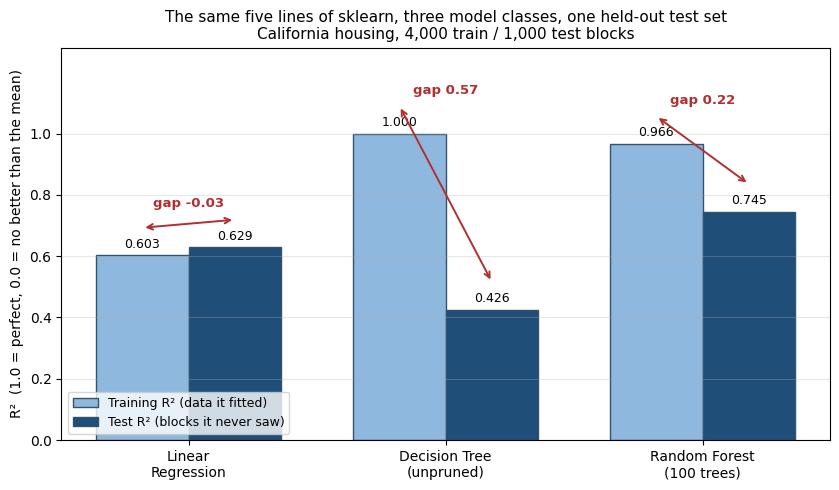

Linear Regression          train R² 0.6028   test R² 0.6289   gap -0.0261
Decision Tree (unpruned)   train R² 1.0000   test R² 0.4258   gap 0.5742
Random Forest (100 trees)  train R² 0.9663   test R² 0.7453   gap 0.2210


In [4]:
# WHAT: Put each regressor's TRAINING R2 next to its TEST R2 on the same axis.
# WHY: The tree printed a training R2 of 1.0000 and a test R2 of 0.43. Two numbers in a
#      paragraph are easy to skim past; the gap between two bars is not.
import matplotlib.pyplot as plt

# Re-use the three models already fitted above - nothing is refitted, so this cell is free.
fitted = [('Linear\nRegression', model_lr),
          ('Decision Tree\n(unpruned)', model_dt_reg),
          ('Random Forest\n(100 trees)', model_rf_reg)]
train_r2 = [r2_score(y_train_reg, m.predict(X_train_reg)) for _, m in fitted]
test_r2 = [r2_score(y_test_reg, m.predict(X_test_reg)) for _, m in fitted]
names = [n for n, _ in fitted]

fig, ax = plt.subplots(figsize=(8.5, 5))
x = range(len(names))
w = 0.36
b1 = ax.bar([i - w / 2 for i in x], train_r2, w, label='Training R² (data it fitted)',
            color='#8fb8de', edgecolor='#33526e')
b2 = ax.bar([i + w / 2 for i in x], test_r2, w, label='Test R² (blocks it never saw)',
            color='#1f4e79', edgecolor='#33526e')
for bars, vals in ((b1, train_r2), (b2, test_r2)):
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.015, f"{v:.3f}",
                ha='center', va='bottom', fontsize=9)

# Draw the generalisation gap as a labelled span above each pair.
for i, (tr, te) in enumerate(zip(train_r2, test_r2)):
    ax.annotate("", xy=(i - w / 2, tr + 0.09), xytext=(i + w / 2, te + 0.09),
                arrowprops=dict(arrowstyle='<->', color='#b03030', linewidth=1.4))
    ax.text(i, max(tr, te) + 0.13, f"gap {tr - te:.2f}", ha='center',
            color='#b03030', fontsize=9.5, weight='bold')

ax.set_xticks(list(x))
ax.set_xticklabels(names)
ax.set_ylabel('R²  (1.0 = perfect, 0.0 = no better than the mean)')
ax.set_ylim(0, 1.28)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_title('The same five lines of sklearn, three model classes, one held-out test set\n'
             f'California housing, {len(X_train_reg):,} train / {len(X_test_reg):,} test blocks',
             fontsize=11)
ax.legend(loc='lower left', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

for name, tr, te in zip([n.replace(chr(10), ' ') for n in names], train_r2, test_r2):
    print(f"{name:26s} train R² {tr:.4f}   test R² {te:.4f}   gap {tr - te:.4f}")


**Read the figure.** Three pairs of bars: the pale bar is the score on the data the model
was fitted on, the dark bar is the score on 1,000 blocks it never saw, and the red arrow
between them is the generalisation gap. Linear regression's pair is almost level — it is too
rigid to memorise anything, and its honest test R² is about 0.63. The unpruned decision tree
reaches a **training R² of 1.0000**: it grew until every training block had its own leaf, so
it reproduces the training set perfectly and still scores the **worst** of the three on the
test bar. The forest averages 100 such trees; its training bar stays high but its test bar is
the tallest in the figure. The lesson is the gap, not the height: a tall pale bar next to a
short dark one is what memorising looks like, and it is invisible if you only report the
training score.

In [5]:
# WHAT: Fit three classifiers on the same real Titanic split and compare accuracy.
# WHY: Same five-line workflow, different model - and a baseline to judge the numbers against.

# PART 3: CLASSIFICATION MODELS
# ============================================================================
print("\n" + "=" * 70)
print("PART 3: Classification Models - predicting Titanic survival")
print("=" * 70)

# Split data
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
baseline = max(y_test_clf.mean(), 1 - y_test_clf.mean())
print(f"Train {len(X_train_clf)} | Test {len(X_test_clf)} passengers")
print(f"Baseline to beat (always predict the majority class): {baseline:.1%}")

# Logistic Regression
print("\n✅ Example 3: Logistic Regression")
print("-" * 70)
model_log = LogisticRegression(random_state=42, max_iter=2000)
model_log.fit(X_train_clf, y_train_clf)
y_pred_log = model_log.predict(X_test_clf)
acc_log = accuracy_score(y_test_clf, y_pred_log)

print(f"   Model: Logistic Regression")
print(f"   Accuracy: {acc_log:.4f} ({acc_log*100:.1f}%)")

# Decision Tree Classifier
print("\n✅ Example 4: Decision Tree Classifier")
print("-" * 70)
model_dt_clf = DecisionTreeClassifier(random_state=42)
model_dt_clf.fit(X_train_clf, y_train_clf)
y_pred_dt_clf = model_dt_clf.predict(X_test_clf)
acc_dt = accuracy_score(y_test_clf, y_pred_dt_clf)

print(f"   Model: Decision Tree Classifier (unpruned)")
print(f"   Accuracy: {acc_dt:.4f} ({acc_dt*100:.1f}%)")

# Random Forest
print("\n✅ Example 5: Random Forest Classifier")
print("-" * 70)
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train_clf, y_train_clf)
y_pred_rf_clf = model_rf.predict(X_test_clf)
acc_rf = accuracy_score(y_test_clf, y_pred_rf_clf)

print(f"   Model: Random Forest Classifier")
print(f"   Accuracy: {acc_rf:.4f} ({acc_rf*100:.1f}%)")

print("\nWhich features did the forest lean on?")
for name, imp in sorted(zip(CLF_FEATURES, model_rf.feature_importances_),
                        key=lambda t: -t[1]):
    print(f"   {name:12s} {imp:.3f}")
ranked = sorted(zip(CLF_FEATURES, model_rf.feature_importances_), key=lambda t: -t[1])
print(f"\n💡 The top three are {ranked[0][0]}, {ranked[1][0]} and {ranked[2][0]} "
      f"({ranked[0][1]:.2f} / {ranked[1][1]:.2f} / {ranked[2][1]:.2f}) - close enough that")
print("   no single feature decides survival. Fare and Pclass both encode wealth, so the")
print("   forest can split on either; that is why importances get shared between them.")

# ============================================================================


PART 3: Classification Models - predicting Titanic survival
Train 712 | Test 179 passengers
Baseline to beat (always predict the majority class): 61.5%

✅ Example 3: Logistic Regression
----------------------------------------------------------------------
   Model: Logistic Regression
   Accuracy: 0.8045 (80.4%)

✅ Example 4: Decision Tree Classifier
----------------------------------------------------------------------
   Model: Decision Tree Classifier (unpruned)
   Accuracy: 0.8101 (81.0%)

✅ Example 5: Random Forest Classifier
----------------------------------------------------------------------


   Model: Random Forest Classifier
   Accuracy: 0.8101 (81.0%)

Which features did the forest lean on?
   Fare         0.309
   is_female    0.265
   Age          0.256
   Pclass       0.085
   SibSp        0.047
   Parch        0.038

💡 The top three are Fare, is_female and Age (0.31 / 0.27 / 0.26) - close enough that
   no single feature decides survival. Fare and Pclass both encode wealth, so the
   forest can split on either; that is why importances get shared between them.


## 💬 Discuss

Six models, one workflow, real data. On California housing: **Linear R² 0.629, single
Decision Tree 0.426 (with training R² of 1.0000), Random Forest 0.745**. On Titanic:
**baseline 61.5%, Logistic 80.4%, Tree 81.0%, Forest 81.0%**.

1. The decision tree scored **R² = 1.0000 on training data and 0.426 on test** — worse than
   plain linear regression. Explain to a client, in two sentences and without the word
   "overfitting", what the tree did and why the forest fixed it.
2. On Titanic, the three models land within 0.6 percentage points of each other, and the
   test set is 179 passengers. Is Random Forest "the best model" here? Compute roughly how
   many passengers separate 80.4% from 81.0%, then answer again.
3. The forest's top features are **Fare 0.309, is_female 0.265, Age 0.256**, and the
   notebook points out Fare and Pclass both encode wealth. If a maritime-safety regulator
   asked "what should we change to save more lives?", which of those importances is
   actionable and which is not? What does that say about using feature importance as an
   explanation?


In [6]:
# WHAT: Print the five-step sklearn workflow (import, create, fit, predict, evaluate) and recap.
# WHY: Every sklearn model - from linear regression to random forests - follows this exact pattern; learn it once, reuse it everywhere.

# PART 4: SCIKIT-LEARN WORKFLOW
# ============================================================================
print("\n" + "=" * 70)
print("PART 4: Scikit-learn Workflow")
print("=" * 70)

print("""
✅ Standard ML Workflow:

1. Import Model
   from sklearn.linear_model import LinearRegression

2. Create Instance
   model = LinearRegression()

3. Fit on Training Data
   model.fit(X_train, y_train)

4. Predict on Test Data
   y_pred = model.predict(X_test)

5. Evaluate Performance
   from sklearn.metrics import mean_squared_error
   mse = mean_squared_error(y_test, y_pred)

💡 This workflow works for ALL scikit-learn models!
""")

# ============================================================================
# ============================================================================
print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
print(f"""
✅ What you learned, measured on real data in this run:

   Regression - California housing ({len(X_reg):,} block groups, test R²):
      Linear Regression   R² = {r2_lr:.3f}   MSE = {mse_lr:.3f}
      Decision Tree       R² = {r2_dt:.3f}   MSE = {mse_dt:.3f}
      Random Forest       R² = {r2_rf:.3f}   MSE = {mse_rf:.3f}

   Classification - Titanic survival ({len(X_clf)} passengers, test accuracy):
      Majority baseline   {baseline:.1%}
      Logistic Regression {acc_log:.1%}
      Decision Tree       {acc_dt:.1%}
      Random Forest       {acc_rf:.1%}

🎯 Key Takeaways:
   - Regression: Predict continuous values (here: median house value)
   - Classification: Predict categories (here: survived / did not)
   - Workflow: Same for all models (fit → predict → evaluate)
   - Real data means honest scores. An R² of {r2_rf:.2f} on housing is a GOOD result;
     if you ever see R² = 0.99 on real-world data, suspect a leak, not a breakthrough.

📚 Next Steps:
   - Example 4: Linear Regression in depth
   - Example 7: Model Evaluation (cross-validation, more metrics)
""")
print("✅ Scikit-learn ML models concepts understood!")


PART 4: Scikit-learn Workflow

✅ Standard ML Workflow:

1. Import Model
   from sklearn.linear_model import LinearRegression

2. Create Instance
   model = LinearRegression()

3. Fit on Training Data
   model.fit(X_train, y_train)

4. Predict on Test Data
   y_pred = model.predict(X_test)

5. Evaluate Performance
   from sklearn.metrics import mean_squared_error
   mse = mean_squared_error(y_test, y_pred)

💡 This workflow works for ALL scikit-learn models!


Summary

✅ What you learned, measured on real data in this run:

   Regression - California housing (5,000 block groups, test R²):
      Linear Regression   R² = 0.629   MSE = 0.501
      Decision Tree       R² = 0.426   MSE = 0.776
      Random Forest       R² = 0.745   MSE = 0.344

   Classification - Titanic survival (891 passengers, test accuracy):
      Majority baseline   61.5%
      Logistic Regression 80.4%
      Decision Tree       81.0%
      Random Forest       81.0%

🎯 Key Takeaways:
   - Regression: Predict continuous

## ⚠️ Where this breaks

- **A uniform API hides non-uniform assumptions.** `LinearRegression` assumes additive
  linear effects and roughly constant error variance; `DecisionTree` assumes axis-aligned
  splits; `LogisticRegression` assumes a linear log-odds. `fit` never complains when the
  assumption is wrong — it just returns a worse model, silently.
- **`.score()` is not the same metric for every estimator.** For regressors it is R²; for
  classifiers, accuracy. Accuracy on the 0.173%-fraud dataset from Unit 2 would be 99.8%
  for a model that predicts "never fraud". Always name the metric you are optimising, and
  always compare it to a baseline — the notebook's 61.5% majority-class line exists for
  exactly that.
- **Default hyperparameters are not neutral.** The unpruned tree above reached training
  R² = 1.0 because sklearn's default has no depth limit. Defaults are chosen to be
  reasonable, not to be right for your data.
- **Feature importances are not explanations, and correlated features corrupt them.** Fare
  and Pclass measure nearly the same thing (r = −0.55 in Unit 2), so the forest splits on
  whichever it happens to see first and the importance is arbitrarily divided between them.
  Permutation importance and SHAP are better, and still not causal.
- **The assumption that must hold: your rows are i.i.d. samples of the population you will
  predict on.** California housing is a 1990 census with the target censored at $500,001
  (Unit 2 lesson 06). A model can be excellent on this data and still be a bad model of
  California house prices today.
- **When sklearn is not the right tool:** for large tabular data with categorical features
  and missing values, XGBoost or LightGBM will beat these defaults with less preprocessing.
  For deep learning, images or text, use a framework built for it. And for small tabular
  datasets in 2026, check what a tabular foundation model scores before you spend a day
  tuning — the point of a baseline is to be beaten, including by you.


## 🔭 State of the field (2026)

What a 2026 practitioner adds to the workflow above is one more row in the comparison table: a
model nobody trained. Tabular foundation models are fitted *in context* — TabPFN-2.5
(Grinsztajn et al., 2025, arXiv:2511.08667) and TabPFN-3 (Grinsztajn et al., 2026,
arXiv:2605.13986), which the technical report scales to roughly a million training rows — and
TabArena (Erickson et al., 2025, arXiv:2506.16791) exists because comparing those against tuned
sklearn and boosting models fairly needed a continuously maintained benchmark with standardised
protocols instead of a fresh table in every paper. So the honest 2026 form of "always try a simple
baseline first" is: linear model, tree, forest — **and** a foundation-model baseline.

Everything in this notebook survives that change, because the change is a change of row, not of
method. The `fit` / `predict` / `score` contract is exactly what makes adding a fourth row a
one-line edit, and it is still how you would evaluate the foundation model itself. Note the
practical limit too: these models need pretrained weights downloaded, so they are not an offline
classroom exercise here, and the scikit-learn workflow is what the official plan examines.


## 📚 References

1. Pedregosa, F., Varoquaux, G., Gramfort, A., et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825-2830. <https://arxiv.org/abs/1201.0490>
2. Buitinck, L., Louppe, G., Blondel, M., et al. (2013). *API Design for Machine Learning Software: Experiences from the scikit-learn Project*. ECML PKDD LML Workshop. <https://arxiv.org/abs/1309.0238>
3. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning*, 2nd ed. Springer. <https://www.statlearning.com>
4. Erickson, N., Purucker, L., Tschalzev, A., et al. (2025). *TabArena: A Living Benchmark for Machine Learning on Tabular Data*. arXiv:2506.16791. <https://arxiv.org/abs/2506.16791>
5. Grinsztajn, L., Flöge, K., Key, O., et al. (2026). *TabPFN-3: Technical Report*. arXiv:2605.13986. <https://arxiv.org/abs/2605.13986>
